# Spacetime Error Visualizations for Surface-Code Circuits

Visualizes **when** (which round) and **what type** of errors occur across a
rotated surface-code memory experiment, using Stim's spacetime / detector
diagrams plus the interactive Crumble editor.

The circuit is built with the **same noise channels** as the trained dataset
(`Stim_generate_datasets.ipynb`):
- `before_round_data_depolarization=p`
- `after_reset_flip_probability=p`
- `after_clifford_depolarization=p`

Trained datasets use `ROUNDS=2`; here we default to `ROUNDS=5` so the spacetime
picture is richer, while keeping the same circuit family.

Each diagram is also written to `plots/*.html` so it can be opened in a browser
and screenshotted for slides. Run with `uv run jupyter ...` (TF 2.15 / Stim env).

In [16]:
# Cell 1 — Imports + build one circuit
import os
from circuit_generators import get_builtin_circuit

# Visualization config. Higher rounds than the trained ROUNDS=2 gives a richer
# spacetime picture; the 3 noise channels match the real dataset circuit family.
VIZ_D, VIZ_P, VIZ_ROUNDS = 5, 0.010, 5

circuit = get_builtin_circuit(
    'surface_code:rotated_memory_z',
    distance=VIZ_D, rounds=VIZ_ROUNDS,
    before_round_data_depolarization=VIZ_P,
    after_reset_flip_probability=VIZ_P,
    after_clifford_depolarization=VIZ_P,
)

os.makedirs('plots', exist_ok=True)
print(circuit.num_ticks, 'ticks')

35 ticks


## 1. Spacetime error graph (interactive 3D)

Built from the detector error model (DEM). Each node is a detector; edges are
error mechanisms that flip a pair of detectors. The vertical axis is time
(rounds), so this shows the full **spacetime** matching structure. Drag to rotate.

In [17]:
# Cell 2 — Spacetime error graph via the DEM.
# decompose_errors=True splits correlated errors into graphlike edges; if a
# circuit can't be decomposed, fall back to the undecomposed DEM.
try:
    dem = circuit.detector_error_model(decompose_errors=True)
except Exception as e:
    print(f'decompose_errors=True failed ({e}); falling back to undecomposed DEM')
    dem = circuit.detector_error_model()

matchgraph = dem.diagram('matchgraph-3d-html')
matchgraph

<!DOCTYPE html>
<html>
<head>
  <meta charset="UTF-8" />
  <script type="importmap">
    {
      "imports": {
        "three": "https://unpkg.com/three@0.138.0/build/three.module.js",
        "three-orbitcontrols": "https://unpkg.com/three@0.138.0/examples/jsm/controls/OrbitControls.js",
        "three-gltf-loader": "https://unpkg.com/three@0.138.0/examples/jsm/loaders/GLTFLoader.js"
      }
    }
  </script>
</head>
<body>
  <a download="model.gltf" id="stim-3d-viewer-download-link" href="data:text/plain;base64,eyJhY2Nlc3NvcnMiOlt7ImJ1ZmZlclZpZXciOjAsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLDAuNDAwMDAwMDA1OTYwNDY0LDAuNDAwMDAwMDA1OTYwNDY0XSwibWluIjpbMCwtMC40MDAwMDAwMDU5NjA0NjQsLTAuNDAwMDAwMDA1OTYwNDY0XSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjEsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLjQwMDAwMDAwNTk2MDQ2NCwwLDAuNDAwMDAwMDA1OTYwNDY0XSwibWluIjpbLTAuNDAwMDAwMDA1OTYwNDY0LDAsLTAuNDAwMDAwMDA1OTYwNDY0XSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjIsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLjQwMDAwMDAwNTk2MDQ2NCwwLjQwMDAwMDAwNTk2MDQ2NCwwXSwibWluIjpbLTAuNDAwMDAwMDA1OTYwNDY0LC0wLjQwMDAwMDAwNTk2MDQ2NCwwXSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjMsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLDAuNDAwMDAwMDA1OTYwNDY0LDAuNDAwMDAwMDA1OTYwNDY0XSwibWluIjpbMCwtMC40MDAwMDAwMDU5NjA0NjQsLTAuNDAwMDAwMDA1OTYwNDY0XSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjQsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLjQwMDAwMDAwNTk2MDQ2NCwwLDAuNDAwMDAwMDA1OTYwNDY0XSwibWluIjpbLTAuNDAwMDAwMDA1OTYwNDY0LDAsLTAuNDAwMDAwMDA1OTYwNDY0XSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjUsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLjQwMDAwMDAwNTk2MDQ2NCwwLjQwMDAwMDAwNTk2MDQ2NCwwXSwibWluIjpbLTAuNDAwMDAwMDA1OTYwNDY0LC0wLjQwMDAwMDAwNTk2MDQ2NCwwXSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjYsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo2NzYyLCJtYXgiOlszMy4zNzA0MjYxNzc5Nzg1LDM5LjQwNzIwNzQ4OTAxMzcsMjEuMjAxNzM2NDUwMTk1M10sIm1pbiI6Wy04LjU0MzU3NjI0MDUzOTU1LC05LjQwNzIwODQ0MjY4Nzk5LC02LjIwMTczNjkyNzAzMjQ3XSwibmFtZSI6ImJ1Zl9zY2F0dGVyZWRfbGluZXMiLCJ0eXBlIjoiVkVDMyJ9LHsiYnVmZmVyVmlldyI6NywiYnl0ZU9mZnNldCI6MCwiY29tcG9uZW50VHlwZSI6NTEyNiwiY291bnQiOjY1MCwibWF4IjpbMzguNTQzNTc1Mjg2ODY1Miw2LDIxLjIwMTczNjQ1MDE5NTNdLCJtaW4iOlstMS4wMjI0NjkwNDM3MzE2OSwtMy4zNzA0MjUyMjQzMDQyLC02LjIwMTczNjkyNzAzMjQ3XSwibmFtZSI6ImJ1Zl9yZWRfc2NhdHRlcmVkX2xpbmVzIiwidHlwZSI6IlZFQzMifV0sImFzc2V0Ijp7InZlcnNpb24iOiIyLjAifSwiYnVmZmVyVmlld3MiOlt7ImJ1ZmZlciI6MCwiYnl0ZUxlbmd0aCI6MTA4LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6MSwiYnl0ZUxlbmd0aCI6MTA4LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6MiwiYnl0ZUxlbmd0aCI6MTA4LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6MywiYnl0ZUxlbmd0aCI6MTA4LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6NCwiYnl0ZUxlbmd0aCI6MTA4LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6NSwiYnl0ZUxlbmd0aCI6MTA4LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6NiwiYnl0ZUxlbmd0aCI6ODExNDQsImJ5dGVPZmZzZXQiOjAsIm5hbWUiOiJidWZfc2NhdHRlcmVkX2xpbmVzIiwidGFyZ2V0IjozNDk2Mn0seyJidWZmZXIiOjcsImJ5dGVMZW5ndGgiOjc4MDAsImJ5dGVPZmZzZXQiOjAsIm5hbWUiOiJidWZfcmVkX3NjYXR0ZXJlZF9saW5lcyIsInRhcmdldCI6MzQ5NjJ9XSwiYnVmZmVycyI6W3siYnl0ZUxlbmd0aCI6MTA4LCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ1cmkiOiJkYXRhOmFwcGxpY2F0aW9uL29jdGV0LXN0cmVhbTtiYXNlNjQsQUFBQUFNM016RDRBQUFBQUFBQUFBTVBRa0Q3RDBKQStBQUFBQVBJd2xyTE56TXcrQUFBQUFNUFFrTDdEMEpBK0FBQUFBTTNNekw3eU1CYXpBQUFBQU1IUWtMN0UwSkMrQUFBQUFQTGtvekhOek15K0FBQUFBTWJRa0Q2LzBKQytBQUFBQU0zTXpENEFBQUFBIn0seyJieXRlTGVuZ3RoIjoxMDgsIm5hbWUiOiJjaXJjbGVfbG9vcCIsInVyaS

**How to read this.** Every **node** is a detector — a stabilizer measurement whose value flipped between rounds, signalling something nearby went wrong. Every **edge** is a single physical error mechanism, connecting the pair of detectors that error lights up. The **vertical axis is time**: an edge running upward is an error visible across consecutive rounds (e.g. a measurement error), while edges within a layer connect neighbouring qubits in one round (a data error). Boundary nodes at the sides absorb errors that flip only one detector.

This is exactly the graph MWPM (PyMatching) matches on: given the lit-up detectors, it finds the most likely set of edges explaining them. So this figure *is* the decoding problem — and the structure your quantized NN decoder learns to solve implicitly from the same syndrome bits. More rounds or higher `p` make the graph taller/denser and the matching harder.

## 2. Per-round detector slices (the "timestamps")

One slice per tick: which detectors are defined at that layer of the circuit.
Reading left-to-right walks through time, round by round.

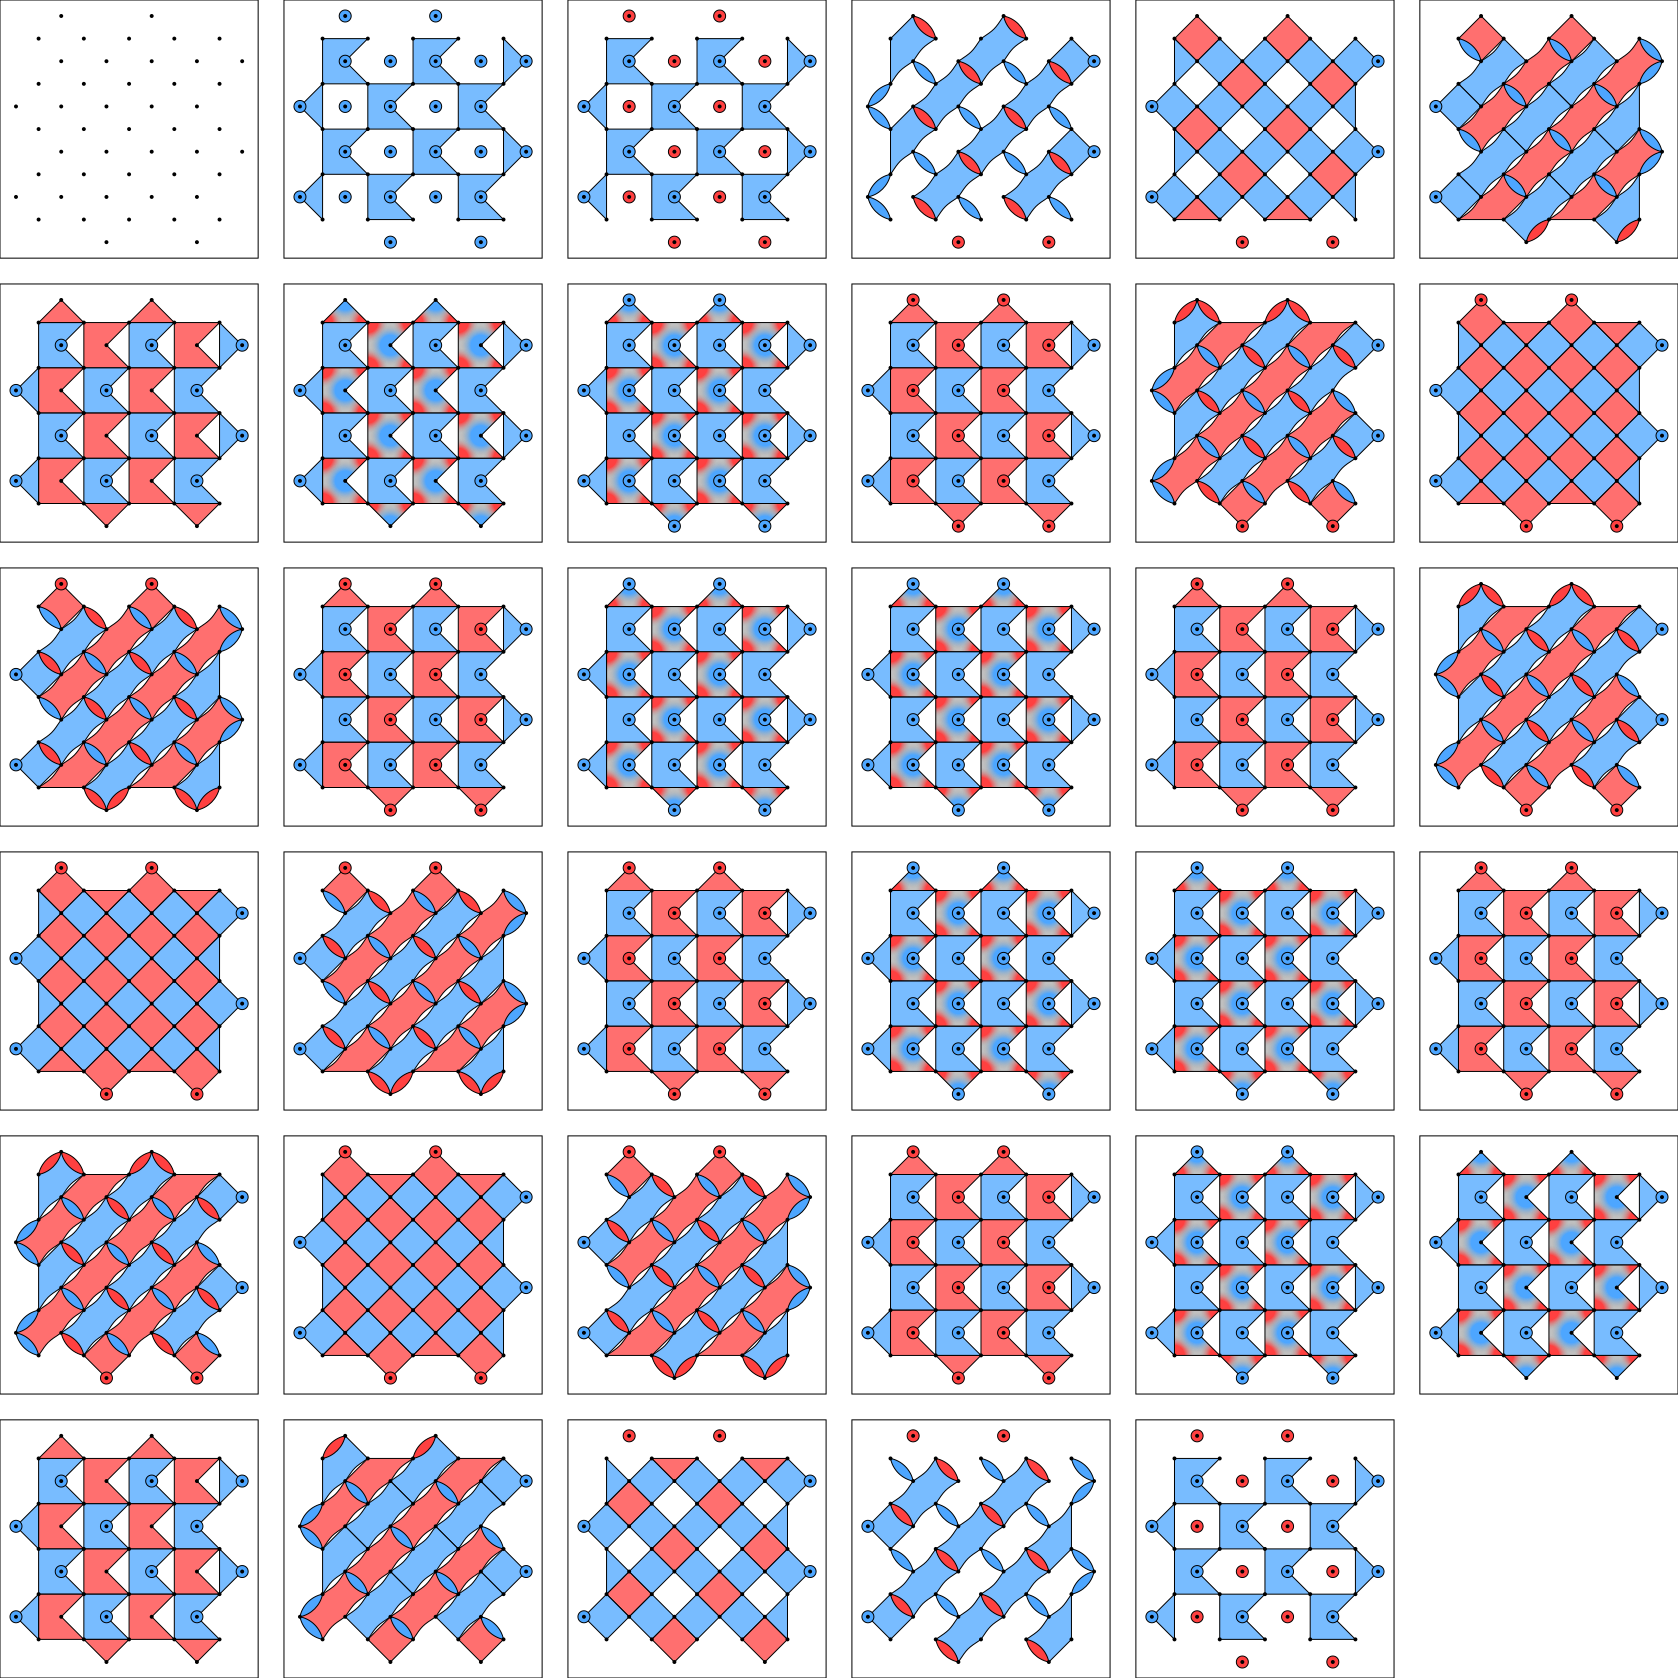

In [18]:
# Cell 3 — Per-round detector slices across every tick.
detslices = circuit.diagram('detslice-svg', tick=range(0, circuit.num_ticks))
detslices

**How to read this.** Each small panel is a single **tick** (circuit time step), shown left-to-right as a timeline. Coloured regions mark the detectors defined at that moment — red/blue correspond to the two stabilizer types (X- and Z-checks). Walking across the strip replays one full experiment: reset → repeated stabilizer rounds → final data readout.

This is the **syndrome being built up over time** — one panel per measurement layer. A single sample in your training set is essentially the sequence of these detector values flattened into the input vector. Use this slide to show *what one dataset example looks like as it is measured round by round*, before any decoder sees it.

## 3. Operations + detectors overlaid ("what happened that layer")

Same per-tick slices, but with the circuit operations (gates, resets,
measurements) drawn on top of the detector regions, so you can see what each
layer actually does.

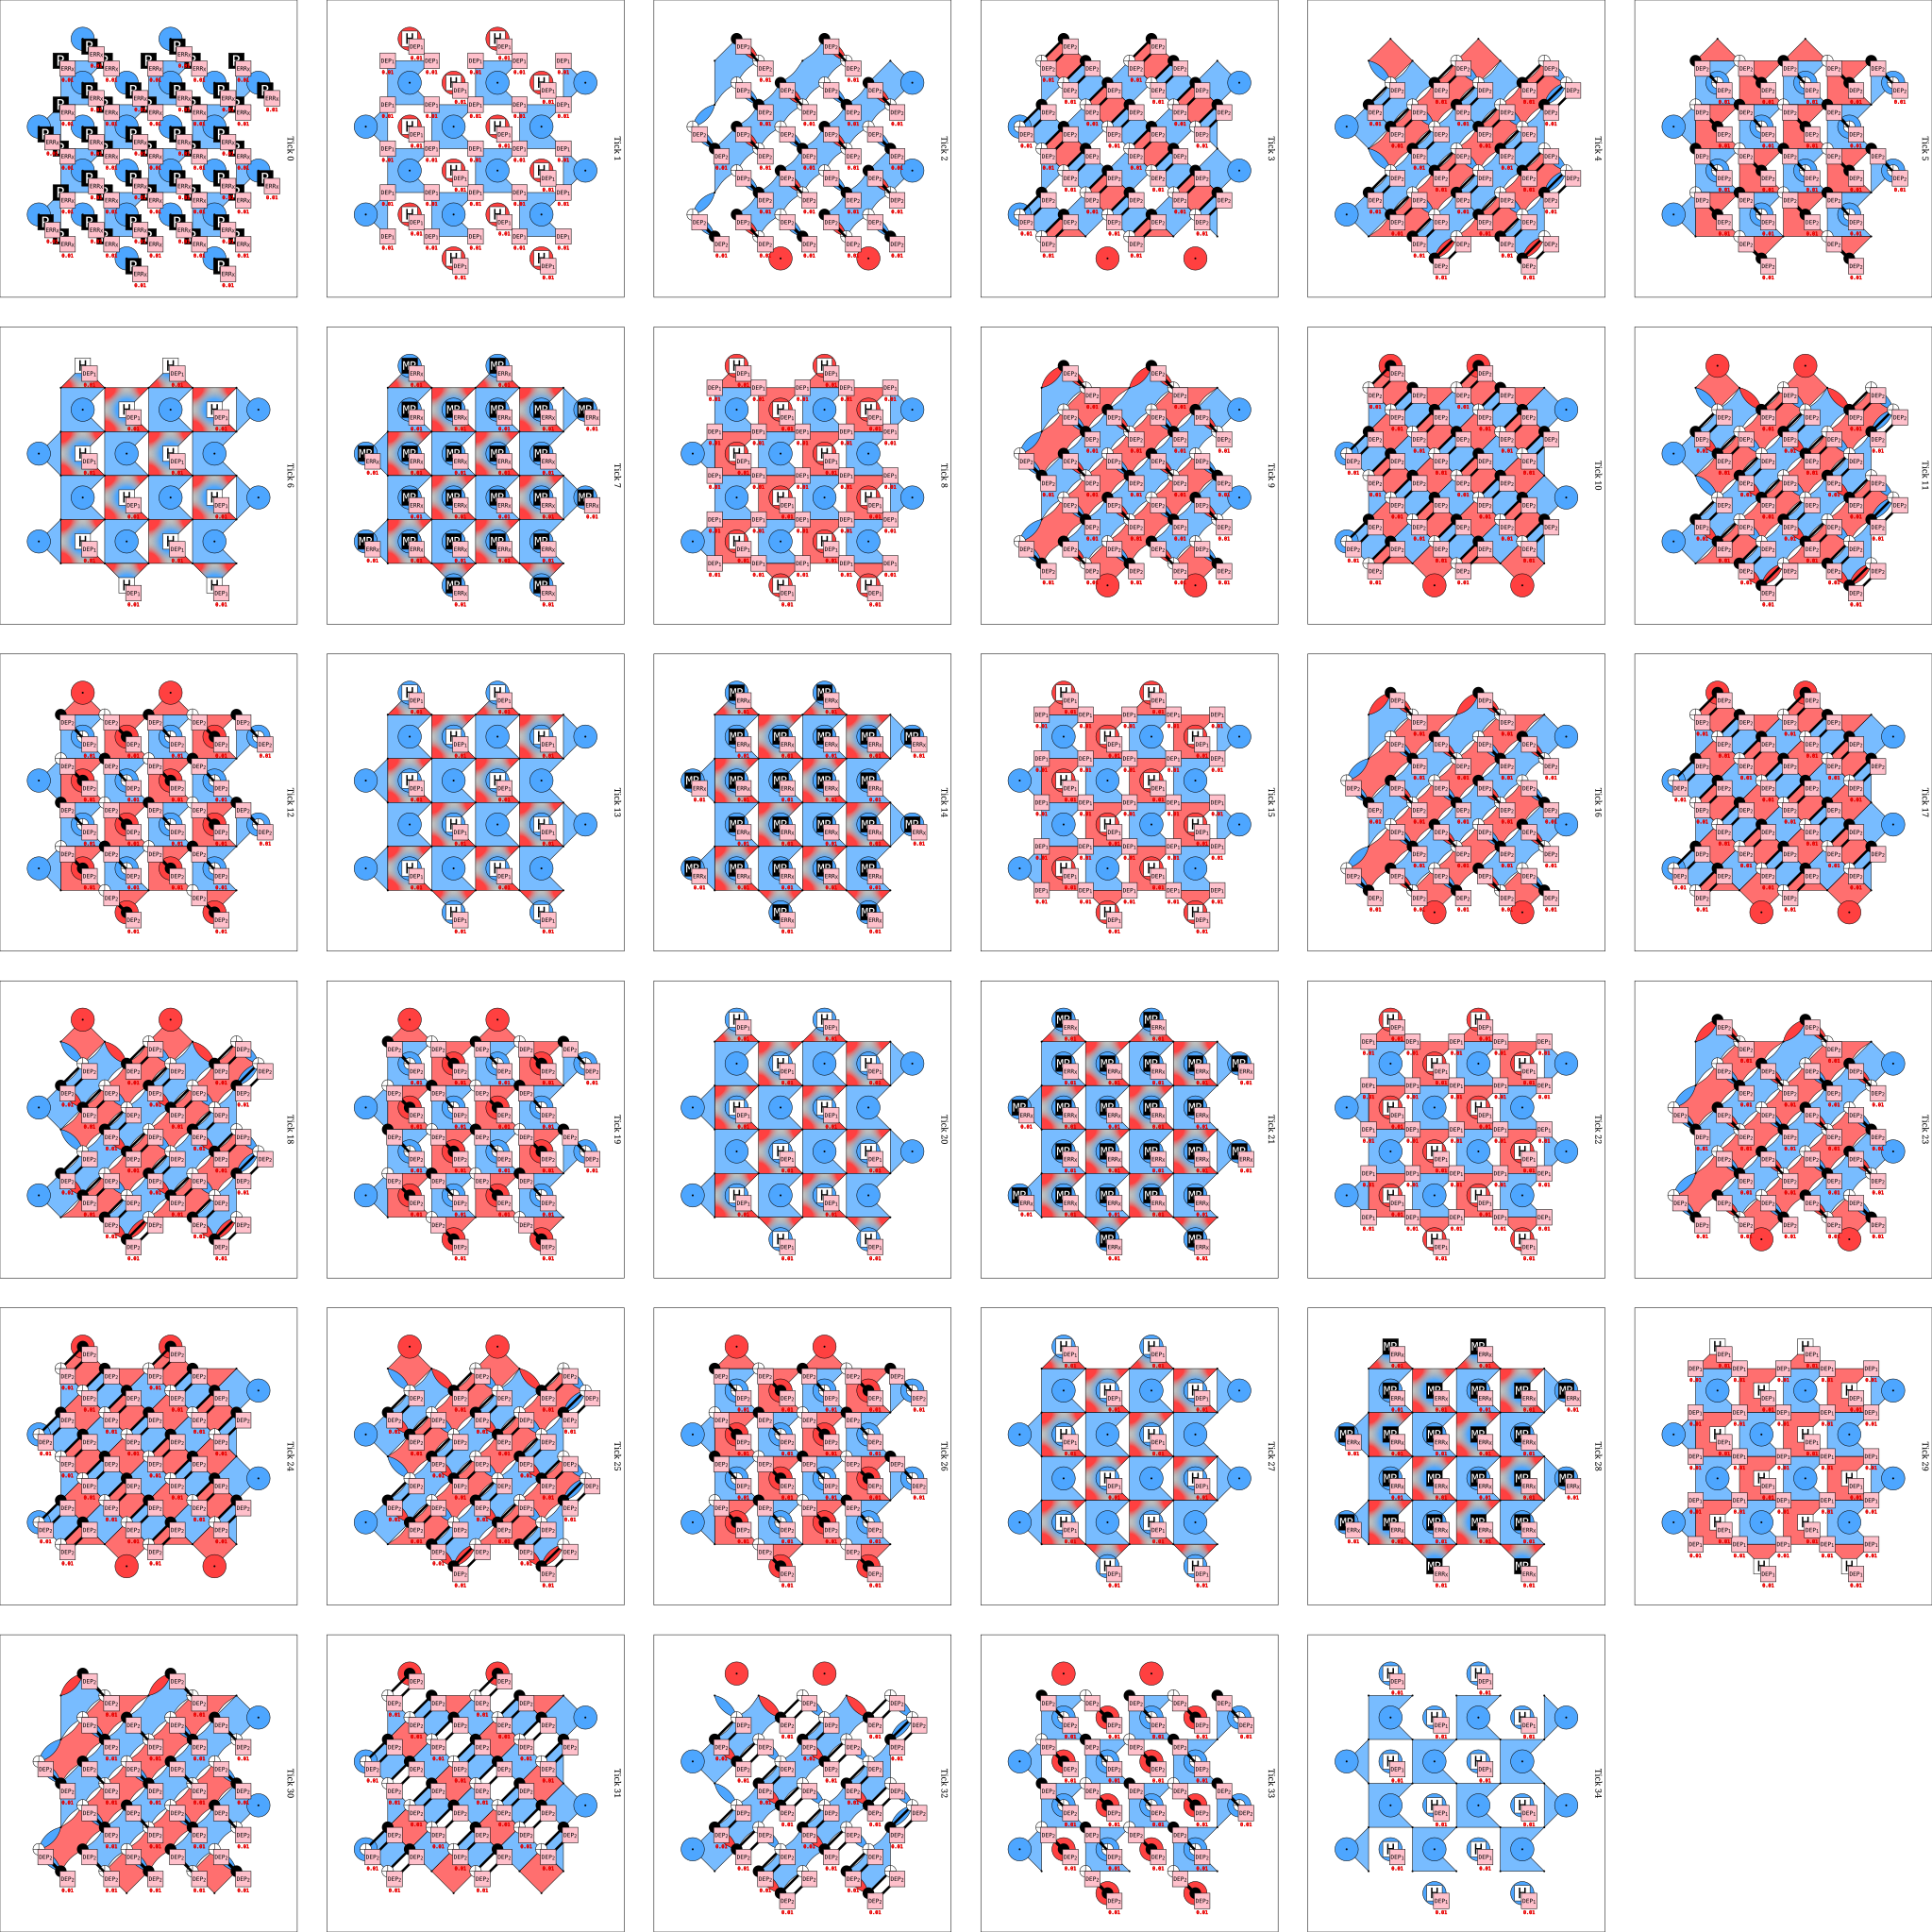

In [19]:
# Cell 4 — Operations overlaid on detector slices.
detslice_ops = circuit.diagram('detslice-with-ops-svg', tick=range(0, circuit.num_ticks))
detslice_ops

**How to read this.** Same per-tick slices as above, but now the actual **circuit operations** are drawn on top: resets (R), two-qubit CX gates (lines between qubits), and measurements (M). So each panel answers *what the hardware physically does* in that layer to produce the detectors, not just which detectors exist.

This is the view to use when explaining **how the syndrome is generated** — the gate schedule that entangles data and ancilla qubits and reads out the stabilizers each round. Pair it with the previous slide: that one shows the syndrome data, this one shows the circuit that creates it.

## 4. Crumble (interactive editor)

Stim's interactive circuit editor. Navigate layers with **Q** / **E**, and
click qubits to inject Paulis and watch them propagate through the circuit.

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Crumble</title>
    <style>
body {
    font-family: sans-serif;
}

#main-container {
    padding: 4px;
    display: flex;
    flex-direction: column;
    height: 100vh;
    box-sizing: border-box;
}

#cvn {
    width: 100%;
    flex: 1;
    min-height: 0;
    border: 1px solid black;
    margin: 0;
    padding: 0;
}

table {
    border: 1px solid black;
    margin: 10px;
    text-align: left;
    border-collapse: collapse;
}

table tr {
    border: 1px solid black;
}
table td {
    border: 1px solid black;
    padding-left: 5px;
    padding-right: 5px;
}
table th {
    border: 1px solid black;
    padding-left: 5px;
    padding-right: 5px;
}

.table-divider {
    border-top: 3px solid black;
}

#button-container {
    display: flex;
    flex-wrap: wrap;
    gap: 4px;
    align-items: flex-start;
}

.btn-group {
    display: flex;
    gap: 2px;
    flex-direction: column;
}

#examples-close-button {
    position: absolute;
    top: 10px;
    right: 10px;
    cursor: pointer;
    font-weight: 900;
}

#toolbox {
    width: 370px;
    height: 110px;
    border: 1px solid black;
    margin: 0;
    padding: 0;
}

#txtStimCircuit {
    width: 95vw;
    height: 300px;
    background-color: #FFFFB0;
}

#btnExport, #btnImport {
    background-color: red;
}
    </style>
    <link rel="shortcut icon" href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAACAAAAAgCAYAAABzenr0AAABgWlDQ1BJQ0MgcHJvZmlsZQAAKJF9kTlIA0EUhj+j4kHEwhQiFluolQFREUuNgggRQlTwKtzdnJBdw27ExlKwDVh4NF6FjbW2FraCIHiAWFpZKdpIWN8kgQQxDgzz8c/8j/f+Ad9RxrTchgGw7JwTnQppC4tLWtMrrfiAAC266WbHI5EwNdfXPXXqvAuqWrXf/bnaYnHXhDpNeMzMOjnhVeGRjVxW8Z7qwkzpMeFz4X5HGhR+VLpR4jfFySKrpgk4c9EJ4YCwlqxio4rNlGMJDwv3xCxb6vsWShxTvKnYyqyb5T7VhP64PT+rdNndTDHNDBE0DNZJkyFHUE5bFJeo3Idq+LuK/oi4DHGlMcUxyRoWetGP+oPf2bqJocFSJX8IGl8876MXmnagkPe872PPK5xA/TNc2RX/2hGMfoqer2g9h9C+BRfXFc3Yhctt6HzK6o5elOpl+xIJeD+Tb1qEjltoXS7lVr7n9AHmJKvwDewfQF9Saq/UmLu5Ord/35Tz+wHVp3JoxsjWZAAAAAlwSFlzAAAuIwAALiMBeKU/dgAAAAd0SU1FB+YKAhYQLxXIct8AAAAZdEVYdENvbW1lbnQAQ3JlYXRlZCB3aXRoIEdJTVBXgQ4XAAAAx0lEQVRYw+2XwQ7EIAhEB+N/E76cnkgIa6OuWTFxvTWxdRgKDwmAYu+i+KDKPP62CJjHNYsQ7Psk8iGk7AxdmeGC1e0CvBBbKQK8ljQB5kK2AxcLsJLMdoBKZvQAULMOtk5IR7Dg294+yw4RymUBs3qQ5bHAO34vC8yFPwvSBFhJ3skC35Bq1sHHsKDGKfUX94J46HllGDjd5XnI5WjOXwXQSg5X95eXaaU3zXSjG3XJ79LW1ak1RsX9/qdsldqsPTppo66k6QGRuElWZ7d4CQAAAABJRU5ErkJggg==">
</head>
<body id="main-container" style="margin: 0">
    <div style="display: inline-block">
        <div>
            <div style="display: inline-block">
                Crumble is a prototype stabilizer circuit editor.<br>
                <br>
                <a href="https://github.com/quantumlib/Stim/blob/main/glue/crumble/README.md">Read the manual</a>
                <br>
                <br>
                <button id="btnShowExamples">Show Example Circuits</button><br>
                <br>
            </div>
            <div style="display: inline-block">
                <canvas id="toolbox">
                </canvas>
            </div>
        </div>
        <div id="button-container">
            <div class="btn-group">
                <button id="btnShowHideImportExport">Show Import/Export</button>
                <button id="clear">Clear All</button>
            </div>
            <div class="btn-group">
                <button id="btnClearMarkers">Clear All Pauli Marks</button>
                <button id="btnClearSelectedMarkers">Clear Selected Marks (space)</button>
            </div>
            <div class="btn-group">
                <button id="btnRedo">Redo (ctrl+Y)</button>
                <button id="btnUndo">Undo (ctrl+Z)</button>
            </div>
            <div class="btn-group">
                <button id="btnNextLayer">Next Layer (e)</button>
                <button id="btnPrevLayer">Prev Layer (q)</button>
            </div>
            <div class="btn-group">
                <button id="btnRotate45">Rotate 45 Clockwise ↻ (t)</button>
               
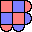

In [20]:
# Cell 5 — Crumble interactive editor.
crumble = circuit.diagram('interactive')
crumble

**How to read this.** Crumble is Stim's interactive playground (opens from the saved `crumble.html`). Use **Q** / **E** to step backward/forward through circuit layers, and click a qubit to inject a Pauli error (X / Y / Z). The editor then **propagates** that error forward and highlights which detectors it eventually trips.

This makes the abstract error model concrete: drop one X error mid-circuit and literally watch it spread and light up a detector pair — the same pair that shows up as an edge in the 3D matchgraph above. Best used as a **live demo** for 'what does a single error actually do?'; for static slides the 3D matchgraph and detector slices screenshot better.

## Save standalone HTML files for slides

Each diagram is written to its own file under `plots/` (gitignored). Open in a
browser and screenshot for slides.

In [21]:
# Cell 6 — Persist each diagram to its own HTML/SVG-in-HTML file.
os.makedirs('plots', exist_ok=True)
for name, helper in [
    ('matchgraph',   matchgraph),
    ('detslices',    detslices),
    ('detslice_ops', detslice_ops),
    ('crumble',      crumble),
]:
    path = f'plots/{name}.html'
    with open(path, 'w') as f:
        f.write(str(helper))
    print(f'wrote {path}')

wrote plots/matchgraph.html
wrote plots/detslices.html
wrote plots/detslice_ops.html
wrote plots/crumble.html
